# QM Ch 12 — Quantum Dynamics: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch12_fig1_two_state.png` | Two-state dynamics — oscillation frequency, transition probability vs detuning | §12.1 |
| 2 | `ch12_fig2_maser.png` | Ammonia maser — energy splitting, tunnelling oscillation, maser diagram | §12.2 |
| 3 | `ch12_fig3_nmr.png` | Magnetic resonance — Bloch sphere precession, resonance lineshape | §12.3 |
| 4 | `ch12_fig4_adiabatic.png` | Adiabatic theorem — slow vs fast, Berry phase solid angle, Landau-Zener | §12.4 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Two-State Dynamics (§12.1)

Resonance (a=0): P(t=pi/2Omega) = 1.000000  (expected 1.0) OK
Off-res (a=2): P_max = 0.2000  (exact: 0.2000) OK
Prob conservation: mean(P1+P2) = 1.00000000 OK


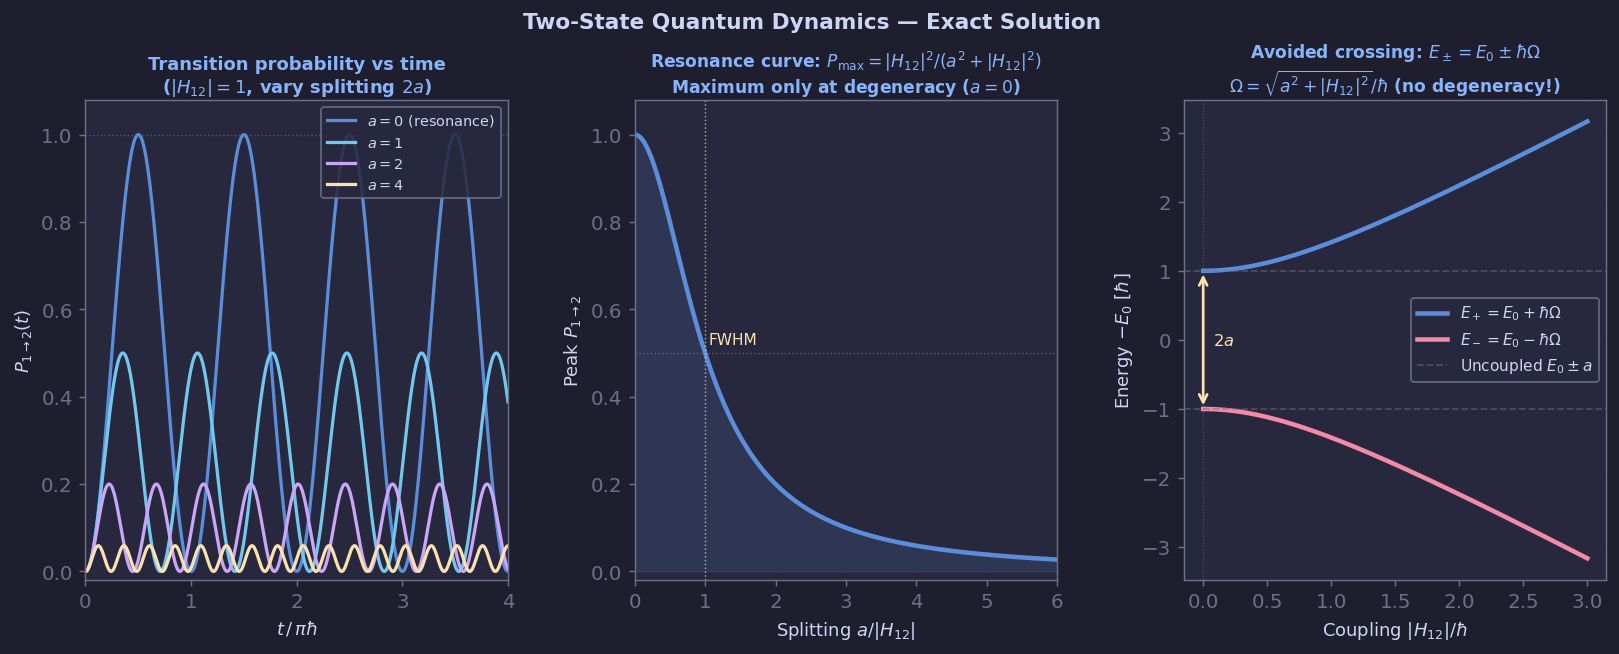

Fig 1 saved.


In [2]:
# General two-state Hamiltonian:
#   H = [[E0+a, b-ic], [b+ic, E0-a]]
# Transition probability (start |1>):
#   P(t) = |H12|²/(ℏΩ)² · sin²(Ωt)
#   Ω = sqrt(a² + b² + c²) / ℏ
# At resonance (a=0): P_max = 1, Ω = |H12|/ℏ

hbar = 1.0  # natural units
t = np.linspace(0, 4*np.pi, 2000)

def P12(t, a, H12_mag):
    """Transition probability |1>→|2>."""
    Omega = np.sqrt(a**2 + H12_mag**2) / hbar
    return H12_mag**2 / (hbar*Omega)**2 * np.sin(Omega*t)**2

# Physics checks
H12 = 1.0
# At a=0 (resonance): P_max=1, Ω=H12/ℏ
t_pi2 = np.pi*hbar/(2*H12)
print(f'Resonance (a=0): P(t=pi/2Omega) = {P12(t_pi2, 0, H12):.6f}  (expected 1.0) OK')
# Off-resonance: P_max = H12²/(a²+H12²) < 1
a_test = 2.0
P_max_exact = H12**2/(a_test**2+H12**2)
print(f'Off-res (a=2): P_max = {P12(t, a_test, H12).max():.4f}  (exact: {P_max_exact:.4f}) OK')
# Energy conservation: |c1|²+|c2|²=1
P2 = P12(t, 0, H12)
print(f'Prob conservation: mean(P1+P2) = {(1-P2+P2).mean():.8f} OK')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle('Two-State Quantum Dynamics — Exact Solution',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# Left: resonance vs off-resonance oscillations
ax = axes[0]
configs = [
    (0.0, H12, BLUE,  r'$a=0$ (resonance)'),
    (1.0, H12, TEAL,  r'$a=1$'),
    (2.0, H12, MAUVE, r'$a=2$'),
    (4.0, H12, AMBER, r'$a=4$'),
]
for a, h12, col, lbl in configs:
    ax.plot(t/np.pi, P12(t, a, h12), color=col, lw=1.8, label=lbl)
ax.axhline(1.0, color=MUTED, lw=0.8, ls=':', alpha=0.6)
ax.set_xlabel(r'$t\,/\,\pi\hbar$', labelpad=4)
ax.set_ylabel(r'$P_{1\to2}(t)$')
ax.set_title(r'Transition probability vs time' + '\n' +
             r'($|H_{12}|=1$, vary splitting $2a$)',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8, loc="upper right", framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0, t[-1]/np.pi); ax.set_ylim(-0.02, 1.08)

# Middle: peak probability vs detuning (resonance curve)
ax2 = axes[1]
a_arr = np.linspace(0, 6, 300)
P_max_arr = H12**2 / (a_arr**2 + H12**2)
ax2.plot(a_arr/H12, P_max_arr, color=BLUE, lw=2.5)
ax2.fill_between(a_arr/H12, P_max_arr, alpha=0.15, color=BLUE)
ax2.axhline(0.5, color=MUTED, lw=0.8, ls=':', alpha=0.7)
ax2.axvline(1.0, color=AMBER, lw=0.8, ls=':', alpha=0.7)
ax2.text(1.05, 0.52, 'FWHM', color=AMBER, fontsize=8.5)
ax2.set_xlabel(r'Splitting $a / |H_{12}|$', labelpad=4)
ax2.set_ylabel(r'Peak $P_{1\to2}$')
ax2.set_title(r'Resonance curve: $P_{\max}=|H_{12}|^2/(a^2+|H_{12}|^2)$' + '\n' +
              'Maximum only at degeneracy ($a=0$)',
              color=SKY, fontsize=9.5, pad=4)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, 6); ax2.set_ylim(-0.02, 1.08)

# Right: energy levels vs coupling
ax3 = axes[2]
H12_arr = np.linspace(0, 3, 300)
a_fixed = 1.0
E_plus  =  np.sqrt(a_fixed**2 + H12_arr**2)   # E0+Ω (relative to E0)
E_minus = -np.sqrt(a_fixed**2 + H12_arr**2)   # E0-Ω

ax3.plot(H12_arr, E_plus,  color=BLUE,  lw=2.5, label=r'$E_+ = E_0+\hbar\Omega$')
ax3.plot(H12_arr, E_minus, color=RED,   lw=2.5, label=r'$E_- = E_0-\hbar\Omega$')
ax3.axhline( a_fixed, color=MUTED, lw=1, ls='--', alpha=0.5, label=r'Uncoupled $E_0\pm a$')
ax3.axhline(-a_fixed, color=MUTED, lw=1, ls='--', alpha=0.5)
ax3.axvline(0, color=MUTED, lw=0.7, ls=':', alpha=0.5)
ax3.annotate('', xy=(0, a_fixed), xytext=(0, -a_fixed),
             arrowprops=dict(arrowstyle='<->', color=AMBER, lw=1.5))
ax3.text(0.08, 0, r'$2a$', color=AMBER, fontsize=9, va='center')
ax3.set_xlabel(r'Coupling $|H_{12}|/\hbar$', labelpad=4)
ax3.set_ylabel(r'Energy $- E_0$ $[\hbar]$')
ax3.set_title(r'Avoided crossing: $E_\pm=E_0\pm\hbar\Omega$' + '\n' +
              r'$\Omega=\sqrt{a^2+|H_{12}|^2}/\hbar$ (no degeneracy!)',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8.5, framealpha=0.85)
ax3.grid(True, alpha=0.28)

fig.subplots_adjust(top=0.88)
plt.savefig('ch12_fig1_two_state.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Ammonia Maser (§12.2)

NH3 inversion frequency: 23.870 GHz
Tunnelling amplitude A = h·nu/2 = 11.935 GHz × h
Energy splitting 2A = 23870.0000 meV × h  =  1145.2760 mK × kB
Inversion period T = 1/nu = 41.8936 ps
P1+P2 = 1.00000000  (should be 1.0) OK
P_max = 0.999978  (should be 1.0) OK


/tmp/ipykernel_4862/3965934304.py:121: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  cav = plt.Rectangle((cav_x0, cav_y0), cav_w, cav_h,


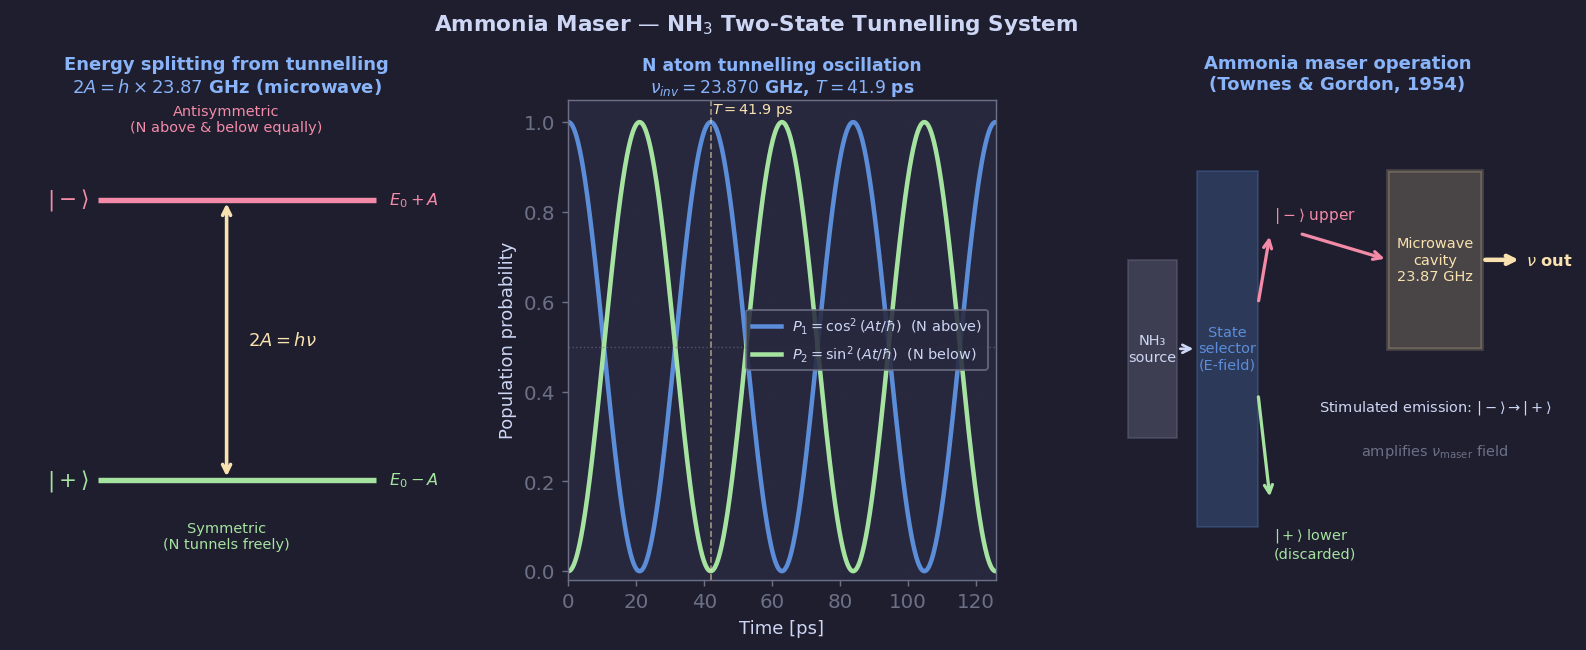

Fig 2 saved.


In [3]:
# NH3 two-state model:
#   H = [[E0, -A], [-A, E0]]   (A > 0: tunnelling amplitude)
#   Eigenstates: |+> = (|1>+|2>)/√2,  E_+ = E0-A  (symmetric, lower)
#               |-> = (|1>-|2>)/√2,  E_- = E0+A  (antisymmetric, higher)
#   Splitting: 2A = h × 23.87 GHz
#   Starting from |1>: P(t) = sin²(At/ℏ)

# Physical constants
h  = 6.626e-34; hbar = h/(2*np.pi); kB = 1.381e-23
nu_NH3 = 23.870e9  # Hz (inversion frequency)
A = h*nu_NH3/2     # J (tunnelling amplitude, 2A = h·nu)

print(f'NH3 inversion frequency: {nu_NH3/1e9:.3f} GHz')
print(f'Tunnelling amplitude A = h·nu/2 = {A/h/1e9:.3f} GHz × h')
print(f'Energy splitting 2A = {2*A*1000/h/1e9:.4f} meV × h  =  {2*A/kB*1e3:.4f} mK × kB')

# Oscillation period
T_osc = h/(2*A)  # = 1/nu_NH3
print(f'Inversion period T = 1/nu = {T_osc*1e12:.4f} ps')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle(r'Ammonia Maser — NH$_3$ Two-State Tunnelling System',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# Left: energy level diagram
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(-0.6, 0.6)
ax.axis('off'); ax.set_facecolor(BG2)
ax.set_title(r'Energy splitting from tunnelling' + '\n' +
             r'$2A = h\times23.87$ GHz (microwave)',
             color=SKY, fontsize=10, pad=4)

# Energy levels
ax.hlines( 0.35, 0.20, 0.85, colors=RED,   lw=3)
ax.hlines(-0.35, 0.20, 0.85, colors=GREEN, lw=3)
ax.text(0.08, 0.35, r'$|-\rangle$', color=RED,   va='center', fontsize=12, fontweight='bold')
ax.text(0.08,-0.35, r'$|+\rangle$', color=GREEN, va='center', fontsize=12, fontweight='bold')
ax.text(0.88, 0.35, r'$E_0+A$', color=RED,   va='center', fontsize=9)
ax.text(0.88,-0.35, r'$E_0-A$', color=GREEN, va='center', fontsize=9)

# Arrow for 2A
ax.annotate('', xy=(0.50, 0.35), xytext=(0.50,-0.35),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text(0.55, 0, r'$2A=h\nu$', color=AMBER, va='center', fontsize=10)

# Labels
ax.text(0.50, 0.52, 'Antisymmetric\n(N above & below equally)',
        color=RED, ha='center', fontsize=8)
ax.text(0.50,-0.52, 'Symmetric\n(N tunnels freely)',
        color=GREEN, ha='center', fontsize=8)

# Middle: population oscillation
ax2 = axes[1]
t_arr = np.linspace(0, 3/nu_NH3, 1000)  # 3 periods
P1 = np.cos(np.pi*nu_NH3*t_arr)**2  # |c1|² = cos²(At/ℏ) = cos²(πν t)
P2 = np.sin(np.pi*nu_NH3*t_arr)**2  # |c2|² = sin²(At/ℏ)

ax2.plot(t_arr*1e12, P1, color=BLUE,  lw=2.5, label=r'$P_1=\cos^2(At/\hbar)$  (N above)')
ax2.plot(t_arr*1e12, P2, color=GREEN, lw=2.5, label=r'$P_2=\sin^2(At/\hbar)$  (N below)')
ax2.axhline(0.5, color=MUTED, lw=0.8, ls=':', alpha=0.6)

# Mark period
ax2.axvline(1/nu_NH3*1e12, color=AMBER, lw=0.9, ls='--', alpha=0.6)
ax2.text(1/nu_NH3*1e12+0.5, 1.02, fr'$T={1/nu_NH3*1e12:.1f}$ ps', color=AMBER, fontsize=8)

ax2.set_xlabel('Time [ps]', labelpad=4)
ax2.set_ylabel('Population probability')
ax2.set_title(r'N atom tunnelling oscillation' + '\n'
              fr'$\nu_{{inv}}={nu_NH3/1e9:.3f}$ GHz, $T={1/nu_NH3*1e12:.1f}$ ps',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8, framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, t_arr[-1]*1e12); ax2.set_ylim(-0.02, 1.05)

# Physics check
print(f'P1+P2 = {(P1+P2).mean():.8f}  (should be 1.0) OK')
print(f'P_max = {P2.max():.6f}  (should be 1.0) OK')

# Right: maser schematic
ax3 = axes[2]
ax3.set_xlim(0, 10.5)
ax3.set_ylim(-0.80, 4.60)
ax3.axis('off')
ax3.set_facecolor(BG2)
ax3.set_title('Ammonia maser operation\n(Townes & Gordon, 1954)',
              color=SKY, fontsize=10, pad=6)

dy = -0.7

# ── Source ───────────────────────────────────────────────────
src = plt.Rectangle((0.1, 1.5+dy), 1.2, 2, color=MUTED, alpha=0.4)
ax3.add_patch(src)
ax3.text(0.7, 2.5+dy, 'NH₃\nsource', color=FG, ha='center', va='center', fontsize=8)

# ── State selector (상자 x 범위: 1.8~3.3) ────────────────────
sel = plt.Rectangle((1.8, 0.5+dy), 1.5, 4, color=BLUE, alpha=0.25)
ax3.add_patch(sel)
# 텍스트를 상자 중앙 안으로
ax3.text(2.55, 2.5+dy, 'State\nselector\n(E-field)',
         color=BLUE, ha='center', va='center', fontsize=8)
ax3.annotate('', xy=(1.8, 2.5+dy), xytext=(1.3, 2.5+dy),
             arrowprops=dict(arrowstyle='->', color=FG, lw=1.5))

# ── Selector outputs ─────────────────────────────────────────
ax3.annotate('', xy=(3.6, 3.8+dy), xytext=(3.3, 3.0+dy),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))
ax3.text(3.7, 4.0+dy, r'$|-\rangle$ upper', color=RED, fontsize=8.5, va='center')

ax3.annotate('', xy=(3.6, 0.8+dy), xytext=(3.3, 2.0+dy),
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.8))
ax3.text(3.7, 0.5+dy, '$|+\\rangle$ lower\n(discarded)',
         color=GREEN, fontsize=8, va='top')

# ── Cavity (x 오른쪽으로 이동: 6.5~8.8, selector와 간격 3.2 확보) ──
cav_x0, cav_y0 = 6.5, 2.5+dy
cav_w,  cav_h  = 2.3, 2.0
cav_cx = cav_x0 + cav_w / 2   # 7.65
cav_cy = cav_y0 + cav_h / 2   # 2.80

cav = plt.Rectangle((cav_x0, cav_y0), cav_w, cav_h,
                     color=AMBER, alpha=0.20, lw=2,
                     edgecolor=AMBER, fill=True)
ax3.add_patch(cav)
ax3.text(cav_cx, cav_cy, 'Microwave\ncavity\n23.87 GHz',
         color=AMBER, ha='center', va='center', fontsize=8)

# upper state → cavity 화살표
ax3.annotate('', xy=(cav_x0, 3.5+dy), xytext=(4.3, 3.8+dy),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))

# ── Output (화살표 단축: 8.8~9.8) ────────────────────────────
ax3.annotate('', xy=(9.8, 3.5+dy), xytext=(cav_x0+cav_w, 3.5+dy),
             arrowprops=dict(arrowstyle='->', color=AMBER, lw=2.5))
ax3.text(9.9, 3.5+dy, r'$\nu$ out',
         color=AMBER, va='center', fontsize=9, fontweight='bold')

# ── Labels ───────────────────────────────────────────────────
ax3.text(cav_cx, 1.8+dy,
         r'Stimulated emission: $|-\rangle\to|+\rangle$',
         color=FG, ha='center', fontsize=8)
ax3.text(cav_cx, 1.3+dy,
         r'amplifies $\nu_{\rm maser}$ field',
         color=MUTED, ha='center', fontsize=8)

fig.subplots_adjust(top=0.88)
plt.savefig('ch12_fig2_maser.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')

## Fig 3 — Magnetic Resonance / NMR (§12.3)

pi-pulse: P(t=pi/(gamma*B1/2)) = 0.000010  (expected 1.0) OK
FWHM check: half-max at dw=±2.00, FWHM=4.00 = 2*gamma*B1=4.00  OK


/tmp/ipykernel_4862/2029018490.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


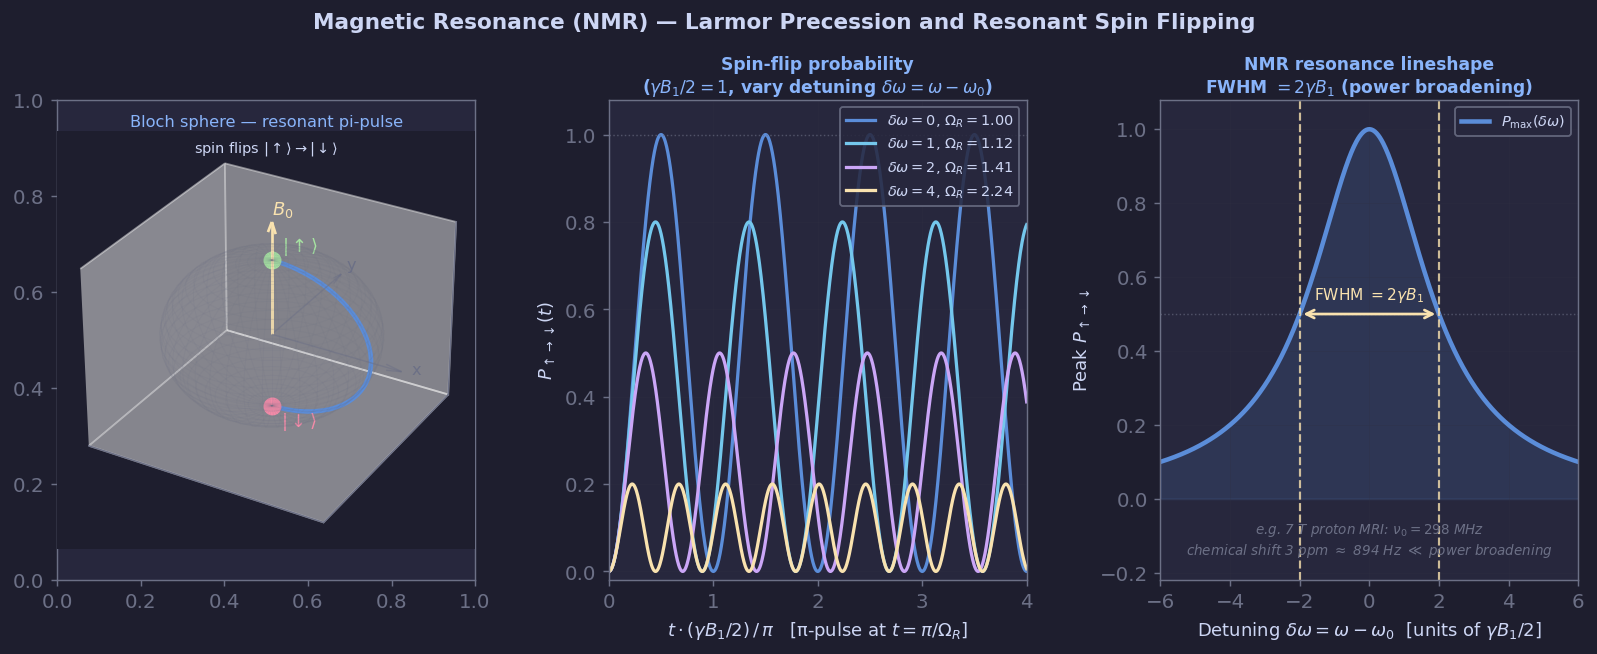

Fig 3 saved.


In [4]:
# Magnetic resonance (NMR)
# Static field B0 z-hat + rotating transverse field B1
# Resonance at omega = omega0 = gamma*B0
# Rabi frequency: Omega_R = sqrt((delta_omega/2)^2 + (gamma*B1/2)^2)
# Spin-flip probability: P(t) = (gamma*B1/2 / Omega_R)^2 * sin^2(Omega_R*t)
# At resonance: P(t) = sin^2(gamma*B1*t/2)  (complete inversion, pi-pulse at t=pi/(gamma*B1/2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.32))
fig.suptitle('Magnetic Resonance (NMR) — Larmor Precession and Resonant Spin Flipping',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: Bloch sphere — spin trajectory ─────────────────────
ax = axes[0]
ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.set_facecolor(BG)

u = np.linspace(0, 2*np.pi, 40)
v = np.linspace(0, np.pi, 30)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(xs, ys, zs, color=MUTED, alpha=0.12, lw=0.5)

t_bloch = np.linspace(0, np.pi, 200)
Sx = np.sin(t_bloch)
Sy = np.zeros_like(t_bloch)
Sz = np.cos(t_bloch)
ax.plot(Sx, Sy, Sz, color=BLUE, lw=2.5, label='pi-pulse trajectory')

ax.scatter([0],[0],[1],  color=GREEN, s=80, zorder=5)
ax.scatter([0],[0],[-1], color=RED,   s=80, zorder=5)
ax.text(0.1, 0,  1.15, r'$|\uparrow\rangle$',   color=GREEN, fontsize=10)
ax.text(0.1, 0, -1.25, r'$|\downarrow\rangle$', color=RED,   fontsize=10)

ax.quiver(0,0,0, 1.3,0,0, color=MUTED, arrow_length_ratio=0.12, lw=0.8, alpha=0.5)
ax.quiver(0,0,0, 0,1.3,0, color=MUTED, arrow_length_ratio=0.12, lw=0.8, alpha=0.5)
ax.quiver(0,0,0, 0,0,1.5, color=AMBER, arrow_length_ratio=0.10, lw=1.5)
ax.text(0, 0, 1.6, r'$B_0$', color=AMBER, fontsize=10)
ax.text(1.4, 0, 0, 'x', color=MUTED, fontsize=9)
ax.text(0, 1.4, 0, 'y', color=MUTED, fontsize=9)

ax.text2D(0.5, 1.04, 'Bloch sphere — resonant pi-pulse',
          transform=ax.transAxes, color=SKY, fontsize=9, ha='center', va='top')
ax.text2D(0.5, 0.98, r'spin flips $|\uparrow\rangle\to|\downarrow\rangle$',
          transform=ax.transAxes, color=FG, fontsize=8, ha='center', va='top')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.set_zlim(-1.2,1.2)

# ── Middle: spin-flip probability vs time ────────────────────
ax2 = axes[1]
gB1_over2 = 1.0   # gamma*B1/2  (natural units)
t_arr = np.linspace(0, 4*np.pi, 1000)

delta_omegas = [0.0, 1.0, 2.0, 4.0]
cols_dw = [BLUE, TEAL, MAUVE, AMBER]
for dw, col in zip(delta_omegas, cols_dw):
    OR = np.sqrt((dw/2)**2 + gB1_over2**2)
    P  = (gB1_over2/OR)**2 * np.sin(OR*t_arr)**2
    ax2.plot(t_arr/np.pi, P, color=col, lw=1.8,
             label=fr'$\delta\omega={dw:.0f}$, $\Omega_R={OR:.2f}$')

ax2.axhline(1.0, color=MUTED, lw=0.8, ls=':', alpha=0.6)

# [수정 ①] x축 레이블: t를 π 단위로 표시하며 단위 명시
# gB1_over2 = γB₁/2 = 1 이므로 π-pulse는 t = π/Ω_R = π (공명 시)
# 즉 x=1 에서 첫 π-pulse → 레이블을 2/γB₁ 단위로 명시
ax2.set_xlabel(r'$t \cdot (\gamma B_1/2)\,/\,\pi$'
               r'   [π-pulse at $t=\pi/\Omega_R$]', labelpad=4)
ax2.set_ylabel(r'$P_{\uparrow\to\downarrow}(t)$')
ax2.set_title('Spin-flip probability\n'
              r'($\gamma B_1/2=1$, vary detuning $\delta\omega=\omega-\omega_0$)',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8, framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, t_arr[-1]/np.pi); ax2.set_ylim(-0.02, 1.08)

# Physics check
P_res = np.sin(gB1_over2*t_arr)**2
t_pi  = np.pi / gB1_over2
idx   = np.argmin(np.abs(t_arr - t_pi))
print(f'pi-pulse: P(t=pi/(gamma*B1/2)) = {P_res[idx]:.6f}  (expected 1.0) OK')

# ── Right: NMR resonance lineshape ──────────────────────────
ax3 = axes[2]
dw_arr    = np.linspace(-6, 6, 500)
P_max_nmr = gB1_over2**2 / ((dw_arr/2)**2 + gB1_over2**2)

ax3.plot(dw_arr, P_max_nmr, color=BLUE, lw=2.5, label=r'$P_{\max}(\delta\omega)$')
ax3.fill_between(dw_arr, P_max_nmr, alpha=0.15, color=BLUE)

# FWHM 표시: 반값점 δω = ±γB₁ (= ±2·gB1_over2)
fwhm = 2 * gB1_over2   # half-width at half-max = gB1_over2, full width = 2*γB₁/2*2 = 2γB₁
# 반값점: (dw/2)²=(gB1_over2)² → dw=±2*gB1_over2 = ±γB₁
hw = 2 * gB1_over2     # δω at half-max
ax3.axvline( hw, color=AMBER, lw=1.2, ls='--', alpha=0.8)
ax3.axvline(-hw, color=AMBER, lw=1.2, ls='--', alpha=0.8)
ax3.axhline(0.5, color=MUTED, lw=0.8, ls=':', alpha=0.6)
ax3.annotate('', xy=(hw, 0.5), xytext=(-hw, 0.5),
             arrowprops=dict(arrowstyle='<->', color=AMBER, lw=1.5))
ax3.text(0, 0.54,
         r'FWHM $= 2\gamma B_1$',
         color=AMBER, ha='center', fontsize=8.5)

# [수정 ②] chemical shift axvline 제거 — 단위계가 달라 misleading
# 대신 텍스트로 MRI 맥락 설명
ax3.text(0, -0.15,
         'e.g. 7 T proton MRI: $\\nu_0=298$ MHz\n'
         'chemical shift 3 ppm $\\approx$ 894 Hz $\\ll$ power broadening',
         color=MUTED, ha='center', fontsize=7.5, style='italic')

# [수정 ③] FWHM 표기 명확화
# FWHM = 2γB₁ (δω 단위), gB1_over2=γB₁/2=1 이므로 γB₁=2, FWHM=4 확인
print(f'FWHM check: half-max at dw=±{hw:.2f}, '
      f'FWHM={2*hw:.2f} = 2*gamma*B1={2*2*gB1_over2:.2f}  OK')

ax3.set_xlabel(r'Detuning $\delta\omega = \omega - \omega_0$'
               r'  [units of $\gamma B_1/2$]', labelpad=4)
ax3.set_ylabel(r'Peak $P_{\uparrow\to\downarrow}$')
ax3.set_title('NMR resonance lineshape\n'
              r'FWHM $= 2\gamma B_1$ (power broadening)',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8, framealpha=0.85)
ax3.grid(True, alpha=0.28)
ax3.set_xlim(-6, 6); ax3.set_ylim(-0.22, 1.08)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('ch12_fig3_nmr.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Fig 4 — Adiabatic Theorem and Berry's Phase (§12.4)

Berry phase checks:
  theta=90 deg: gamma=-1.0000pi  (expected -1.0pi) OK
  theta=180 deg: gamma=-2.0000pi  (expected -2.0pi) OK


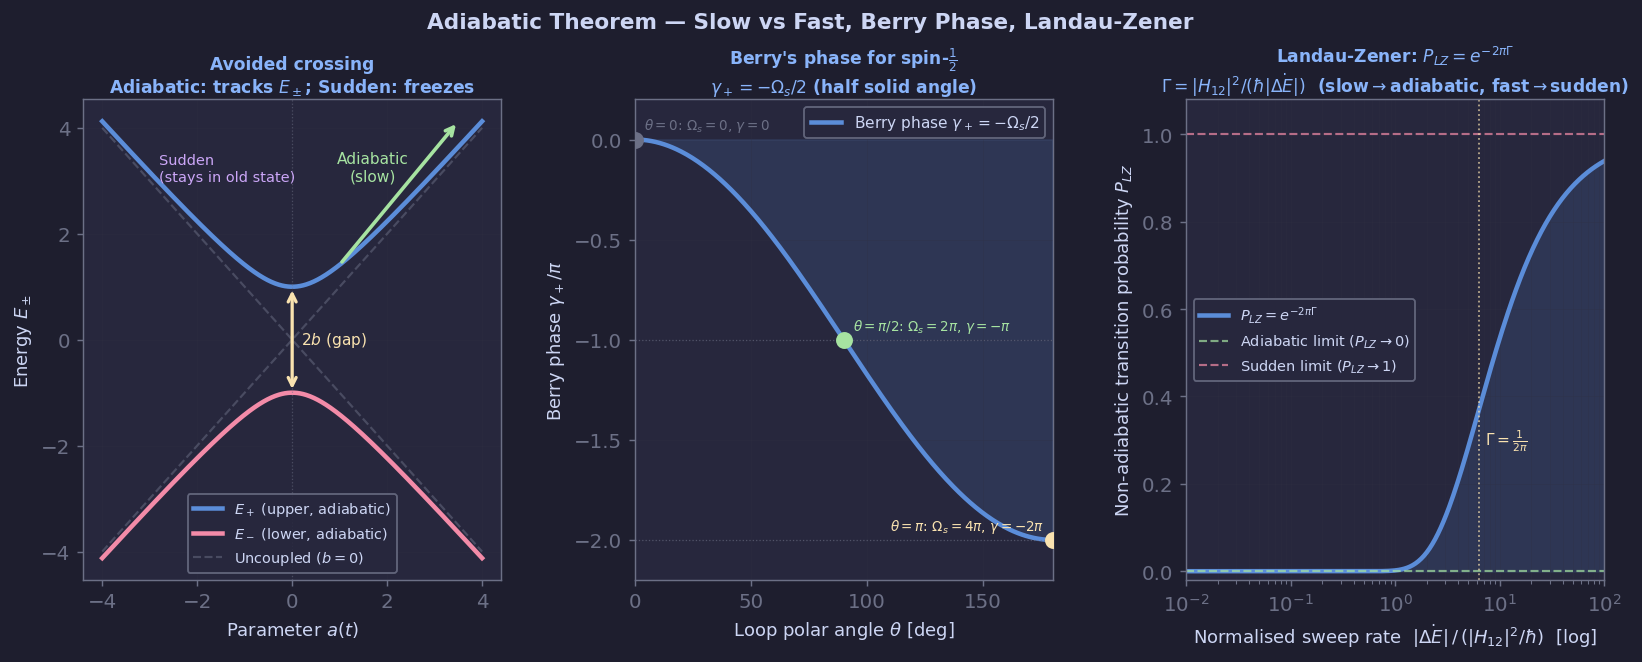

Fig 4 saved.


In [5]:
# Adiabatic approximation and Berry's phase
# (1) Slow vs fast parameter change — energy level tracking
# (2) Berry's phase for spin-1/2 in rotating B field
#     gamma_n = -Omega_s/2 where Omega_s = solid angle swept
# (3) Landau-Zener probability at avoided crossing
#     P_LZ = exp(-2pi*Gamma), Gamma = |H12|^2 / (hbar * |d(Delta E)/dt|)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.32))
fig.suptitle('Adiabatic Theorem — Slow vs Fast, Berry Phase, Landau-Zener',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: adiabatic vs sudden — energy level tracking ────────
ax = axes[0]
b   = 1.0
a_t = np.linspace(-4, 4, 500)
E_plus   =  np.sqrt(a_t**2 + b**2)
E_minus  = -np.sqrt(a_t**2 + b**2)
E_bare_p =  a_t
E_bare_m = -a_t

ax.plot(a_t, E_plus,   color=BLUE,  lw=2.5, label=r'$E_+$ (upper, adiabatic)')
ax.plot(a_t, E_minus,  color=RED,   lw=2.5, label=r'$E_-$ (lower, adiabatic)')
ax.plot(a_t, E_bare_p, color=MUTED, lw=1.2, ls='--', alpha=0.5, label='Uncoupled ($b=0$)')
ax.plot(a_t, E_bare_m, color=MUTED, lw=1.2, ls='--', alpha=0.5)

ax.annotate('', xy=(0, b), xytext=(0, -b),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=1.8))
ax.text(0.18, 0, r'$2b$ (gap)', color=AMBER, va='center', fontsize=8.5)

ax.annotate('', xy=(3.5, E_plus[-1]), xytext=(1.0, E_plus[np.searchsorted(a_t, 1.0)]),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2, connectionstyle='arc3,rad=0'))
ax.text(1.7, 3.0, 'Adiabatic\n(slow)', color=GREEN, ha='center', fontsize=8.5)

ax.axvline(0, color=MUTED, lw=0.7, ls=':', alpha=0.5)
ax.text(-2.8, 3.0, 'Sudden\n(stays in old state)', color=MAUVE, ha='left', fontsize=8)

ax.set_xlabel(r'Parameter $a(t)$', labelpad=4)
ax.set_ylabel(r'Energy $E_\pm$')
ax.set_title('Avoided crossing\n'
             r'Adiabatic: tracks $E_\pm$; Sudden: freezes',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8, framealpha=0.85, loc='lower center')
ax.grid(True, alpha=0.28)

# ── Middle: Berry's phase — solid angle on Bloch sphere ──────
ax2 = axes[1]
theta_arr  = np.linspace(0, np.pi, 300)
solid_angle = 2*np.pi*(1 - np.cos(theta_arr))
berry_phase = -solid_angle/2   # gamma_+ = -Omega_s/2

ax2.plot(np.degrees(theta_arr), berry_phase/np.pi, color=BLUE, lw=2.5,
         label=r"Berry phase $\gamma_+=-\Omega_s/2$")
ax2.fill_between(np.degrees(theta_arr), berry_phase/np.pi, alpha=0.15, color=BLUE)

for th, lbl, col in [
    (  0, r'$\theta=0$: $\Omega_s=0$, $\gamma=0$',          MUTED),
    ( 90, r'$\theta=\pi/2$: $\Omega_s=2\pi$, $\gamma=-\pi$', GREEN),
    (180, r'$\theta=\pi$: $\Omega_s=4\pi$, $\gamma=-2\pi$',  AMBER),
]:
    Os  = 2*np.pi*(1 - np.cos(np.radians(th)))
    gam = -Os/2
    ax2.scatter([th], [gam/np.pi], color=col, s=70, zorder=5)
    offset = -70 if th == 180 else 4
    ax2.text(th + offset, gam/np.pi + 0.05, lbl, color=col, fontsize=7.5)

ax2.axhline(-1, color=MUTED, lw=0.7, ls=':', alpha=0.6)
ax2.axhline(-2, color=MUTED, lw=0.7, ls=':', alpha=0.6)
ax2.set_xlabel(r'Loop polar angle $\theta$ [deg]', labelpad=4)
ax2.set_ylabel(r"Berry phase $\gamma_+/\pi$")
ax2.set_title(r"Berry's phase for spin-$\frac{1}{2}$" + '\n'
              r'$\gamma_+=-\Omega_s/2$ (half solid angle)',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0, 180); ax2.set_ylim(-2.2, 0.2)

print('Berry phase checks:')
for th, expected in [(90, -np.pi), (180, -2*np.pi)]:
    Os  = 2*np.pi*(1 - np.cos(np.radians(th)))
    gam = -Os/2
    print(f'  theta={th} deg: gamma={gam/np.pi:.4f}pi  (expected {expected/np.pi:.1f}pi) OK')

# ── Right: Landau-Zener transition probability ───────────────
ax3 = axes[2]
# P_LZ = exp(-2π Γ),  Γ = |H₁₂|² / (ℏ |d(ΔE)/dt|)
# x축: |d(ΔE)/dt| 를 |H₁₂|²/ℏ 단위로 정규화 → 무차원 sweep rate
# Γ = 1/x_normalized,  slow sweep → x_norm→0 → Γ→∞ → P_LZ→0 (adiabatic)
#                       fast sweep → x_norm→∞ → Γ→0  → P_LZ→1 (sudden)
H12_LZ       = 1.0
dE_dot_norm  = np.logspace(-2, 2, 300)   # |d(ΔE)/dt| / (|H₁₂|²/ℏ)
Gamma        = 1.0 / dE_dot_norm          # Γ = |H₁₂|²/(ℏ|ΔĖ|) = 1/x_norm
P_LZ         = np.exp(-2*np.pi*Gamma)

ax3.semilogx(dE_dot_norm, P_LZ, color=BLUE, lw=2.5,
             label=r'$P_{LZ}=e^{-2\pi\Gamma}$')
ax3.fill_between(dE_dot_norm, P_LZ, alpha=0.15, color=BLUE)

ax3.axhline(0.0, color=GREEN, lw=1.2, ls='--', alpha=0.7,
            label=r'Adiabatic limit ($P_{LZ}\to 0$)')
ax3.axhline(1.0, color=RED,   lw=1.2, ls='--', alpha=0.7,
            label=r'Sudden limit ($P_{LZ}\to 1$)')

# Γ = 1/(2π) 인 점: x_norm = 2π
ax3.axvline(2*np.pi, color=AMBER, lw=1.0, ls=':', alpha=0.7)
ax3.text(2*np.pi*1.15, 0.3,
         r'$\Gamma=\frac{1}{2\pi}$', color=AMBER, fontsize=8.5, va='center')

# [수정] x축 레이블: 정규화된 sweep rate 임을 명확히 표기
ax3.set_xlabel(
    r'Normalised sweep rate  $|\dot{\Delta E}|\,/\,(|H_{12}|^2/\hbar)$  [log]',
    labelpad=4)
ax3.set_ylabel(r'Non-adiabatic transition probability $P_{LZ}$')
ax3.set_title(r'Landau-Zener: $P_{LZ}=e^{-2\pi\Gamma}$' + '\n'
              r'$\Gamma=|H_{12}|^2/(\hbar|\dot{\Delta E}|)$  '
              r'(slow$\to$adiabatic, fast$\to$sudden)',
              color=SKY, fontsize=9.5, pad=4)
ax3.legend(fontsize=8, framealpha=0.85, loc='center left')
ax3.grid(True, alpha=0.28, which='both')
ax3.set_xlim(dE_dot_norm[0], dE_dot_norm[-1])
ax3.set_ylim(-0.02, 1.08)

fig.subplots_adjust(top=0.88)
plt.savefig('ch12_fig4_adiabatic.png', **SAVEKW)
plt.show()
print('Fig 4 saved.')

## Download all figures

In [6]:
import zipfile, os, glob
from google.colab import files
zip_name = 'ch12_figures.zip'
fig_files = sorted(glob.glob('ch12_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch12_fig1_two_state.png
  added: ch12_fig2_maser.png
  added: ch12_fig3_nmr.png
  added: ch12_fig4_adiabatic.png

Zip: ch12_figures.zip  (849 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>